Benjamin Arnold; 10/04/2026; Lab 6: Spinning and Rolling Objects

Part A-- The Physical Pendulum

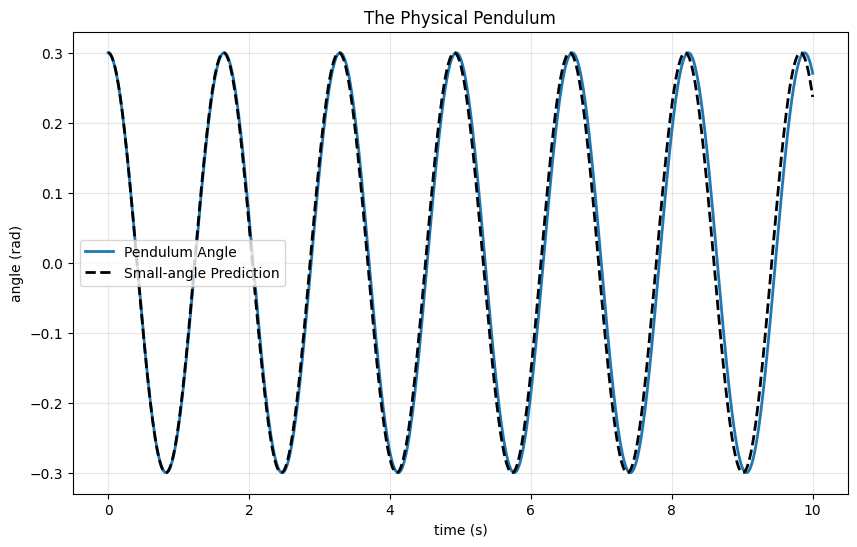

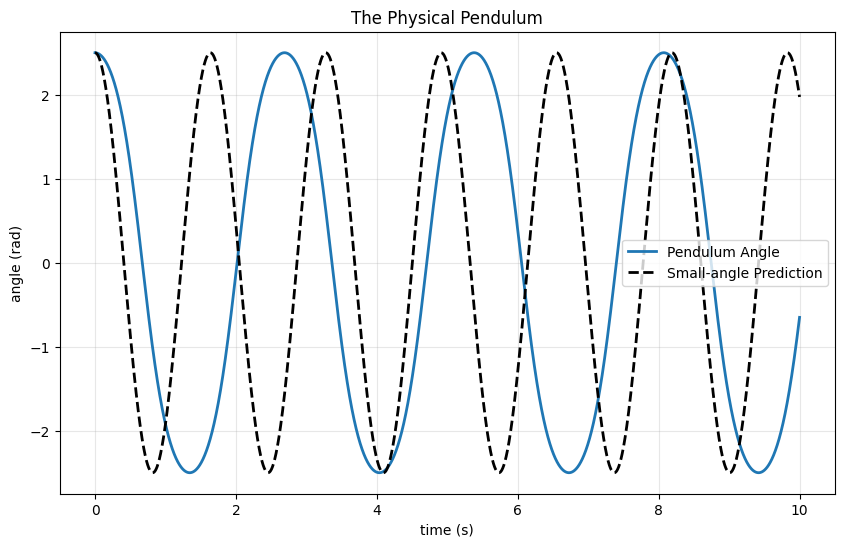

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def moment_of_inertia(masses,positions,axis):
    total=0.0
    for m,r in zip(masses,positions):
        total+=m*np.sum((np.asarray(r)-np.asarray(axis))**2)
    return total

def rotate_step(theta,omega,torque,I,dt):
    alpha=torque/I
    omega=omega+alpha*dt
    theta=theta+omega*dt
    return theta,omega

m,g,d=1.0,9.81,0.5
I =(1/3)*m*(2*d)**2 
def torque(theta):
    return -m*g*d*np.sin(theta)

t=np.linspace(0,10,10000)
def small_angle_prediction(theta,t):
    omega=np.sqrt(m*g*d/I)
    return theta*np.cos(omega*t)

phi=small_angle_prediction(0.3,t)

theta,omega=0.3,0.0
dt=0.001
theta_arr=[]
for _ in range(10000):
    theta,omega=rotate_step(theta,omega,torque(theta),I,dt)
    theta_arr.append(theta)

plt.figure(figsize=(10, 6))
plt.plot(t, theta_arr, linewidth=2, label='Pendulum Angle')
plt.plot(t, phi, linewidth=2, linestyle='--', color='black', label='Small-angle Prediction')
plt.xlabel('time (s)')
plt.ylabel('angle (rad)')
plt.title('The Physical Pendulum')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

phi=small_angle_prediction(2.5,t)

theta,omega=2.5,0.0
dt=0.001
theta_arr=[]
for _ in range(10000):
    theta,omega=rotate_step(theta,omega,torque(theta),I,dt)
    theta_arr.append(theta)

plt.figure(figsize=(10, 6))
plt.plot(t, theta_arr, linewidth=2, label='Pendulum Angle')
plt.plot(t, phi, linewidth=2, linestyle='--', color='black', label='Small-angle Prediction')
plt.xlabel('time (s)')
plt.ylabel('angle (rad)')
plt.title('The Physical Pendulum')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Note: At a large amplitude, the real period is longer than what the small-angle equation predicts. 

Part B-- The Rolling Race

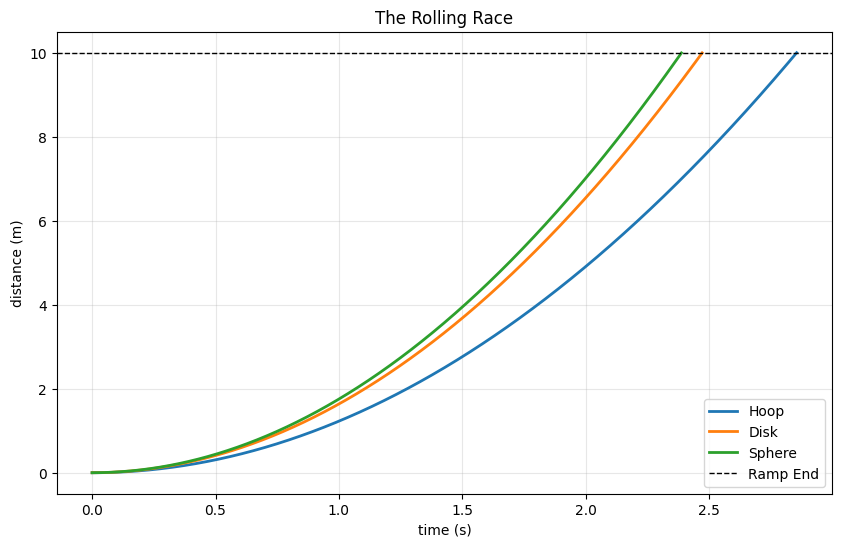

Race Results: The sphere is 1st at 2.39s, the disk is 2nd at 2.47s, and the hoop is 3rd at 2.85s.


In [33]:
def rolling_accel(theta_incline,c,g=9.81):
    return g*np.sin(theta_incline)/(1+c)

ramp_length=10
theta_incline=30*(np.pi/180)
dt=0.001
def EulerCromer_step(r,v,c,dt,g):
    a=rolling_accel(theta_incline,c,g)

    v_new=v+a*dt
    r_new=r+v_new*dt
    return r_new, v_new

def race(c):
    r_arr=[]
    t_arr=[]
    r,v=0.0,0.0
    t=0.0
    
    while r<=ramp_length:
        r_arr.append(r)
        t_arr.append(t)
        r,v=EulerCromer_step(r,v,c,dt,9.81)
        t=t+dt
        
    return t_arr,r_arr

t_hoop,r_hoop=race(1.0)
t_disk,r_disk=race(0.5)
t_sphere,r_sphere=race(0.4)

plt.figure(figsize=(10, 6))
plt.plot(t_hoop, r_hoop, linewidth=2, label='Hoop')
plt.plot(t_disk, r_disk, linewidth=2, label='Disk')
plt.plot(t_sphere, r_sphere, linewidth=2, label='Sphere')
plt.axhline(y=ramp_length, color='black', linestyle='--', linewidth=1, label='Ramp End')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.title('The Rolling Race')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Race Results: The sphere is 1st at {t_sphere[-1]:.2f}s, the disk is 2nd at {t_disk[-1]:.2f}s, and the hoop is 3rd at {t_hoop[-1]:.2f}s.')